#### 주성분 분석(PCA : Pricipal Component Analysis)
: 고차원의 데이터를 저차원의 데이터로 환원시키는 기법

In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [ ]:
# 2차원 배열로 바꾼다. 머신러닝은 2차원밖에 모르니까
fruits_2d = fruits.reshape(-1,100*100)
fruits_2d.shape

(300, 10000)

### PCA 모델 구성하기

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50) # 300개 데이터 중 구별이 확실한 50개를 선택
pca.fit(fruits_2d)

PCA(n_components=50)

In [7]:
# 축소된 차원 크기 확인
pca.components_.shape

(50, 10000)

In [8]:
import matplotlib.pyplot as plt

In [9]:
def draw_fruits(arr, ratio=1): # ratio : 해상도
  n = len(arr)
  # 한 줄에 10개씩 이미지를 생성. 샘플 갯수를 10으로 나누어 전체 행 갯수를 계산.
  rows = int(np.ceil(n/10))
  # 행이 1개이면 열 갯수는 샘플갯수 이다. 그렇지 않으면 10개 입니다.
  cols = n if rows < 2 else 10

  _, axs = plt.subplots(
    rows,
    cols,
    figsize=(cols*ratio, rows*ratio),
    squeeze=False
  )
  for i in range(rows):
    for j in range(cols):
      if i*10+j < n:
        axs[i,j].imshow(arr[i*10+j], cmap='gray_r')
      axs[i,j].axis('off')
  plt.show()

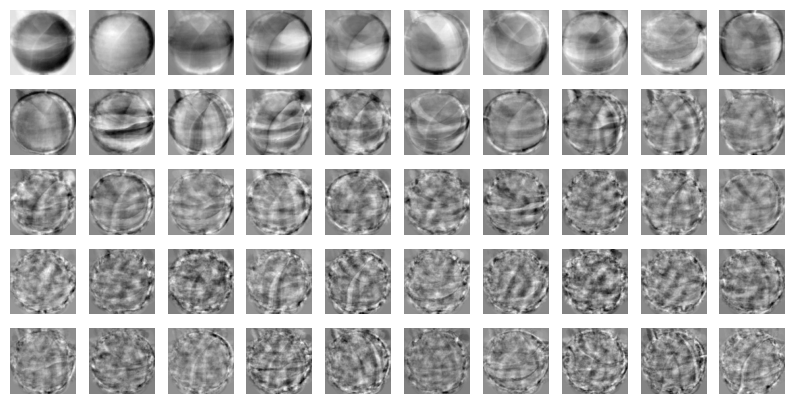

In [ ]:
# 그림으로 확인하기 : Feature를 다시 2차원으로 바꾸어 그린다.
draw_fruits(pca.components_.reshape(-1,100,100))
# 그림 하나하나가 model

In [13]:
# 행의 갯수는 원본과 동일하게 하고 Feature의 특성을 50개의 주성분으로 변경하기
print(fruits_2d.shape)
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 10000)
(300, 50)


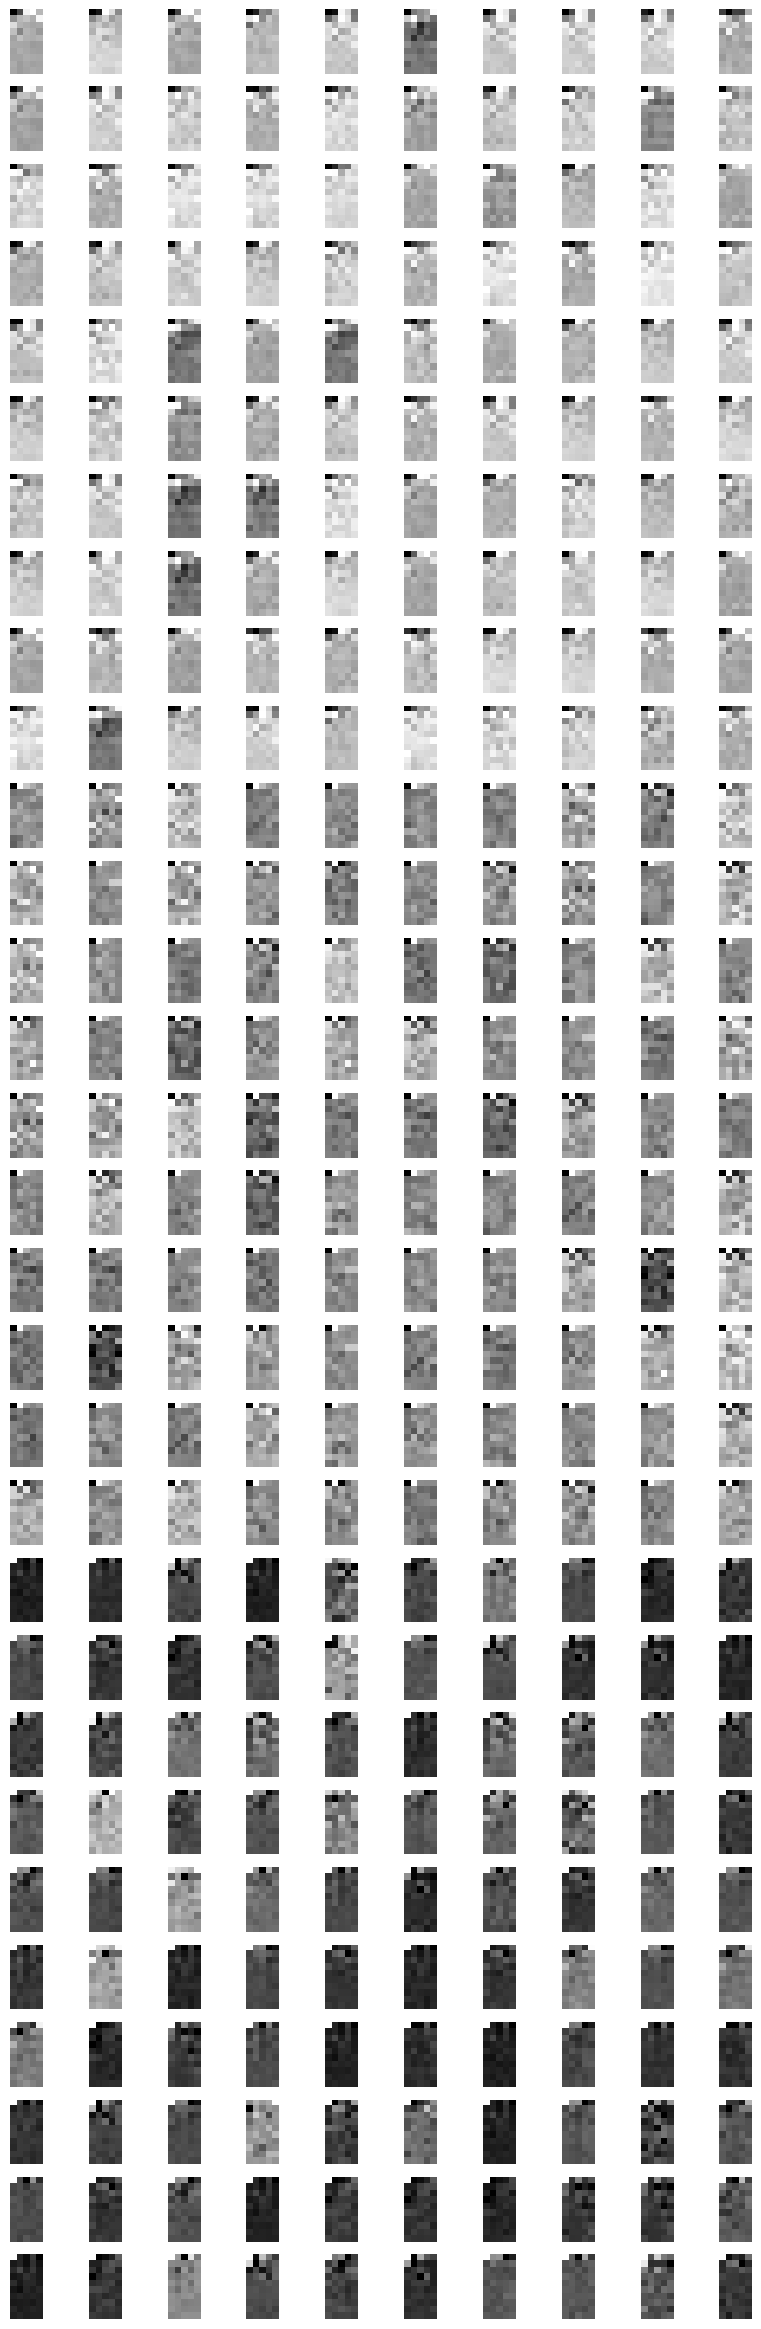

In [14]:
draw_fruits(fruits_pca.reshape(-1,10,5))

---
### 원본데이터 재구성

In [15]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


In [16]:
# 그림을 그려보자
fruits_reconstruct = fruits_inverse.reshape(-1,100,100)
fruits_reconstruct.shape

(300, 100, 100)

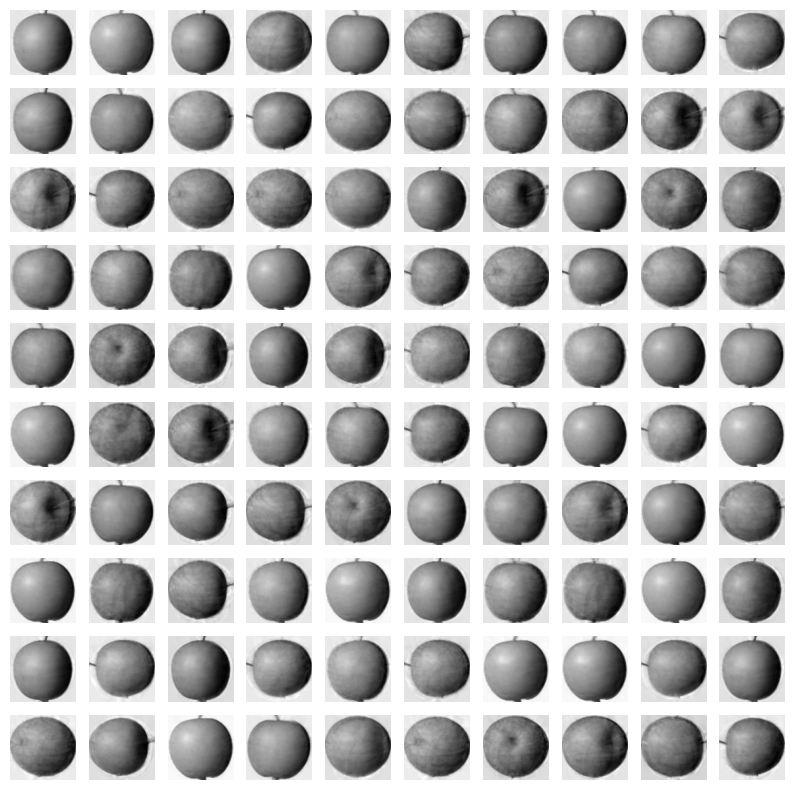

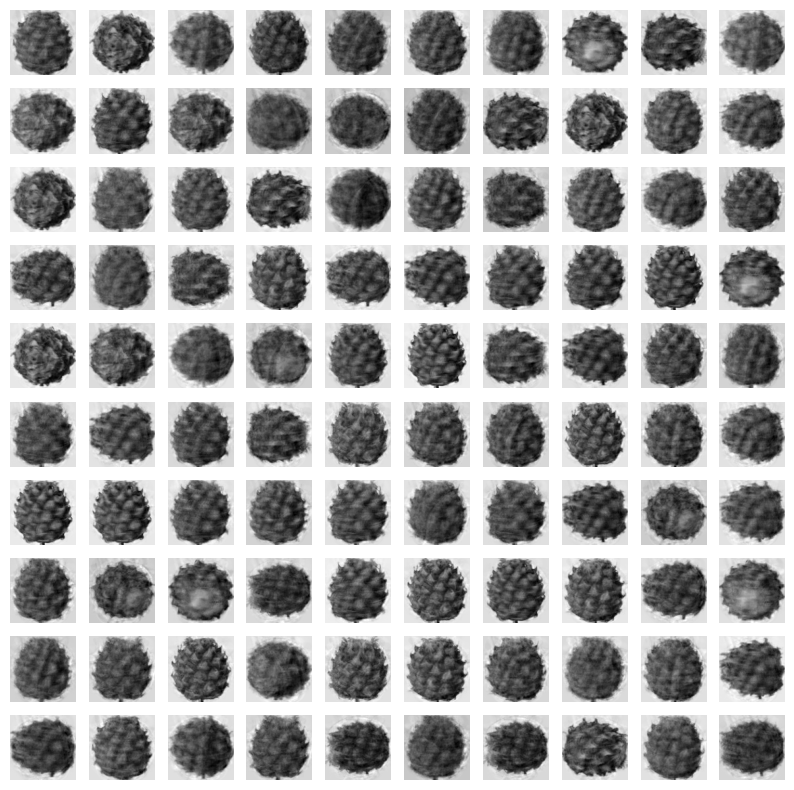

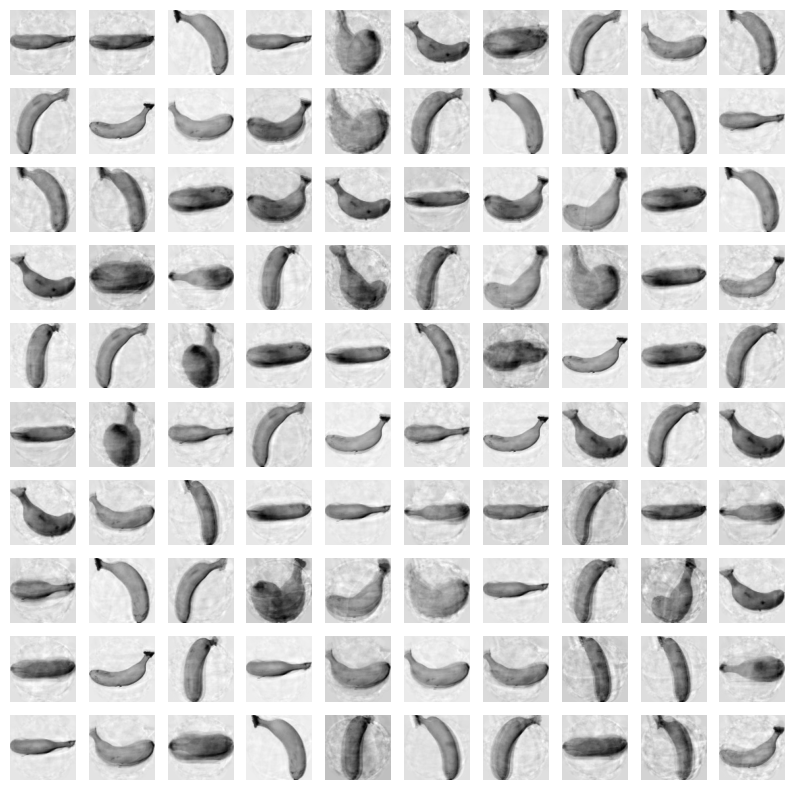

In [17]:
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print("\n")

> 1/200의 데이터 특성만 가지고도 전반적을오 깨끗하지 않으나 물체의 구분은 가능하다.

----
#### 설명된 분산
: 주성분으로 구성할 때 원본 데이터의 분산을 어느정도 유지하고 있었는지 확인하는 방법

In [18]:
np.sum(pca.explained_variance_ratio_)

0.9223138612854623

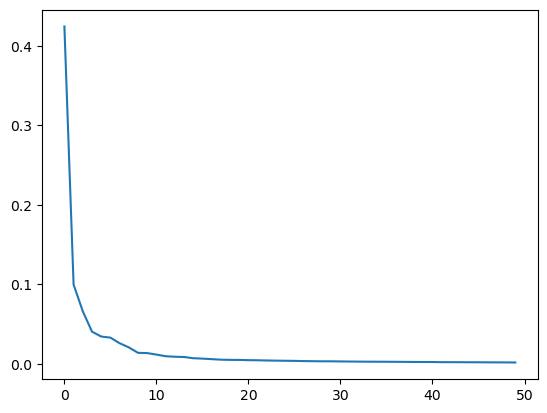

In [19]:
plt.plot(pca.explained_variance_ratio_)
plt.show()

> 10개 정도만 주성분을 잡아도 문제 없을 것 같아 보인다.

#### 주성분을 10개만 잡아서 해보자

In [20]:
pca10 = PCA(n_components=10)
pca10.fit(fruits_2d)

PCA(n_components=10)

In [21]:
pca10.components_.shape

(10, 10000)

In [22]:
fruits_pca10 = pca10.transform(fruits_2d)
fruits_pca10.shape

(300, 10)

In [23]:
fruits_inverse10 = pca10.inverse_transform(fruits_pca10)
fruits_inverse10.shape

(300, 10000)

In [24]:
fruits_reconstruct10 = fruits_inverse10.reshape(-1,100,100)
fruits_reconstruct10.shape

(300, 100, 100)

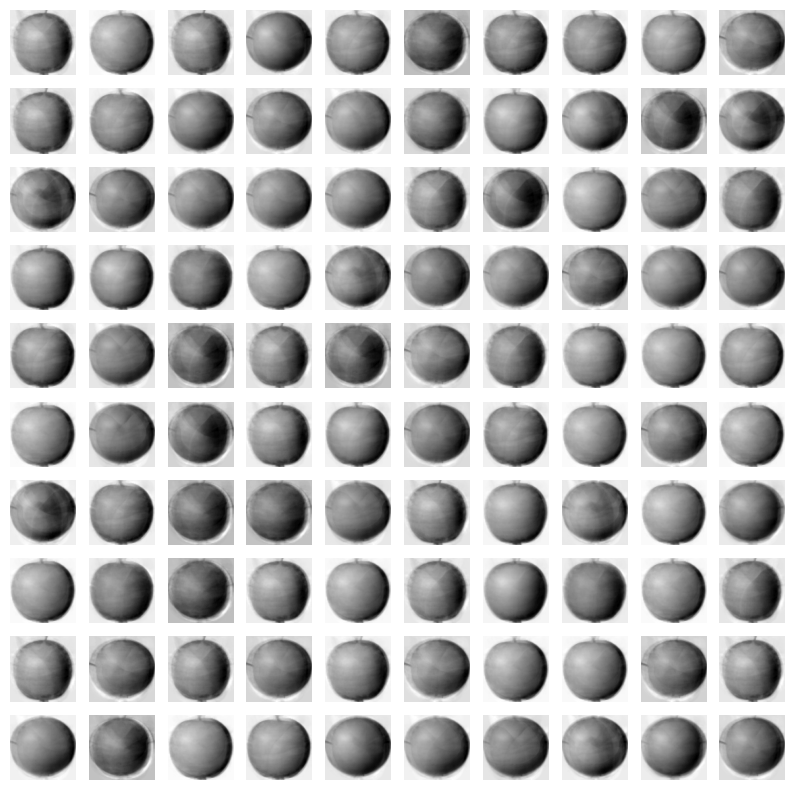

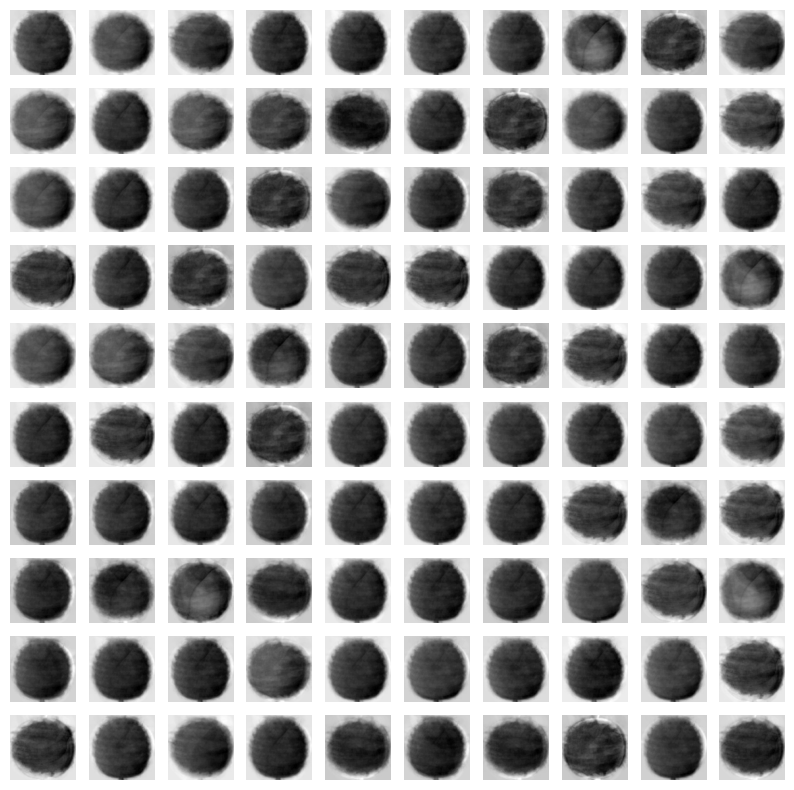

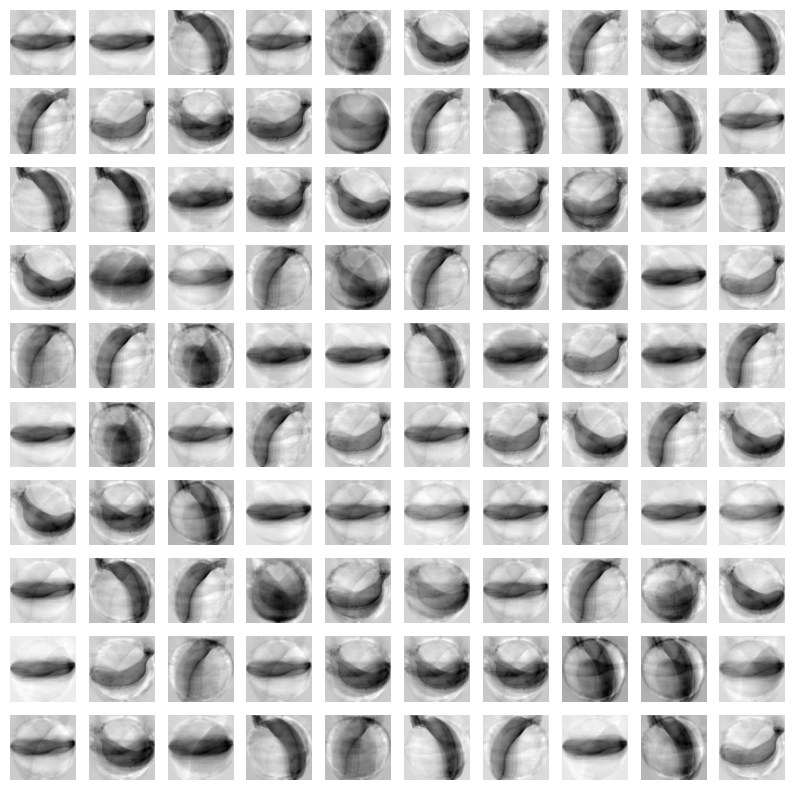

In [25]:
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct10[start:start+100])
  print("\n")

In [26]:
np.sum(pca10.explained_variance_ratio_)

0.7711096068798833

---
#### 로지스틱 회귀분석에 주성분 분석을 대입하여 사용해보기

In [27]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [28]:
# 로지스틱 회귀는 지도학습 이므로 Target이 필요하다.
target = np.array([0]*100 + [1]*100 + [2]*100)

In [29]:
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [30]:
# 교차검증을 통해 실시
from sklearn.model_selection import cross_validate

scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.09801697731018066


In [31]:
# 300 * 50으로 구성된 주성분 분석으로 구성된 데이터로 확인

scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.003941011428833008


----
#### 주성분 분석의 분산의 크기를 정해 사용하기

In [32]:
pca = PCA(n_components=0.5) # n_components를 실수(정수는 갯수로 정의된다)로 정의하면 분산의 percent정도를 나타낸다.
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [34]:
pca.n_components_

2

In [35]:
fruits_pca = pca.transform(fruits_2d)
fruits_pca.shape

(300, 2)

In [36]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.004797744750976563


In [38]:
# 주성분의 값을 알아보자
pcaComponets = pca.fit_transform(fruits_2d)

import pandas as pd
pcaDf = pd.DataFrame(data=pcaComponets, columns=['PCA1', 'PCA2'])
pcaDf.head()

,PCA1,PCA2
0,2776.498471,1580.322486
1,3075.909684,2734.476728
2,2616.828977,1496.477291
3,3113.625578,2527.080543
4,2519.267133,2323.854018


---
#### k-Means에 주성분 분석 적용해보기

In [39]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)

KMeans(n_clusters=3, random_state=42)

In [40]:
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


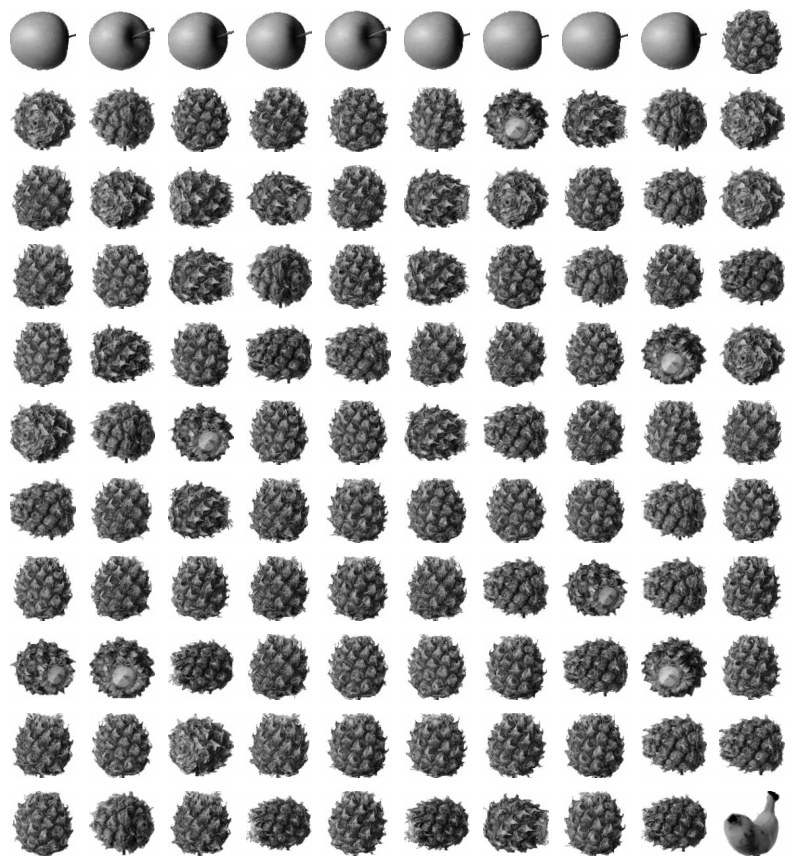

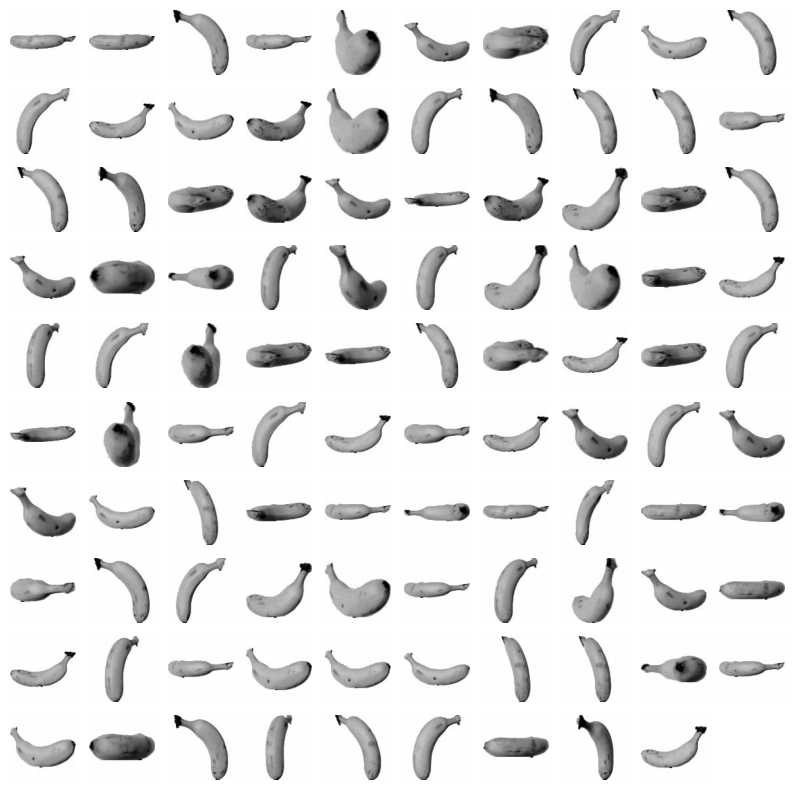

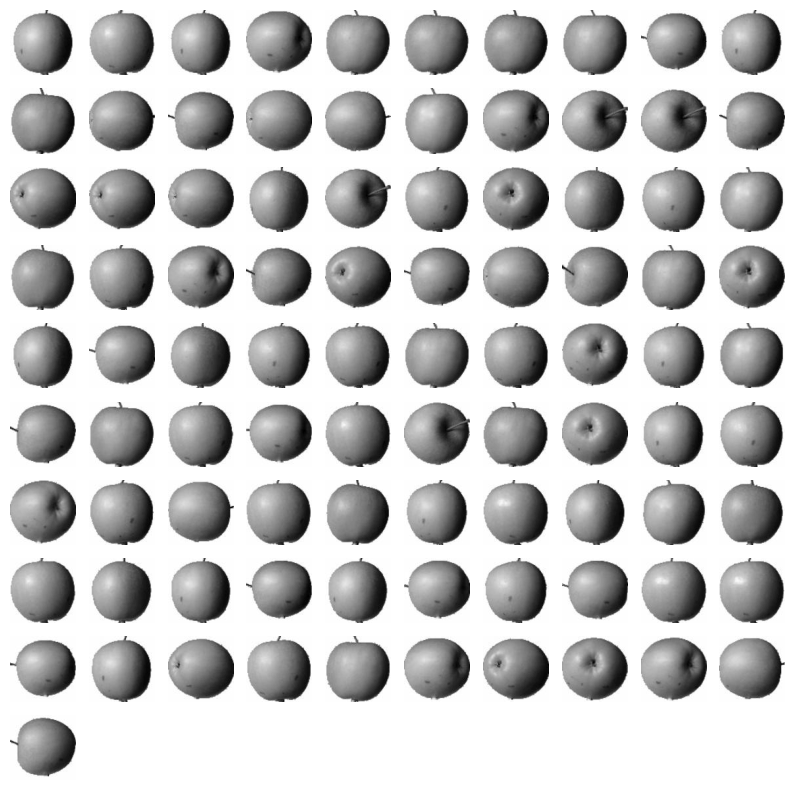

In [41]:
for label in range(3):
  draw_fruits(fruits[km.labels_ == label])
  print("\n")

---
#### 산포도로 확인해 보기

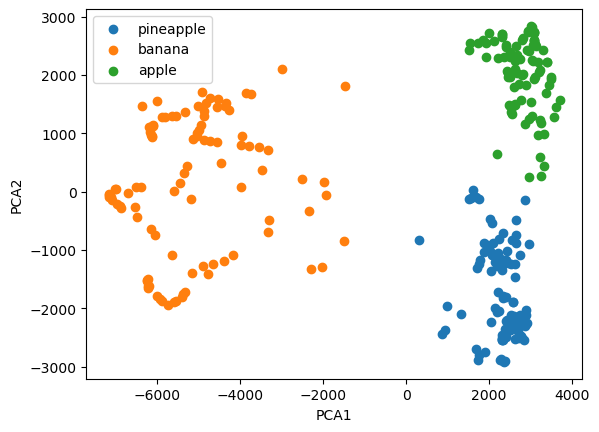

In [44]:
for label in range(3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:, 0], data[:, 1])
plt.legend(['pineapple', 'banana', 'apple'])
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()
